# Document Analysis System

This notebook aims to develop a document  analysis system using LangGraph to serve Mr. Wayne's need. This system can:

1. Process images document

2. Extract text using vision models (Vision Language Model)

3. Perform calculations when needed (to demonstrate normal tools)

4. Analyze content and provide concise summaries

5. Execute specific instructions related to documents

In [13]:
# !pip install langgraph langchain_openai langchain_core

In [14]:
import base64
from typing import List, TypedDict, Annotated, Optional
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

In [ ]:
class AgentState(TypedDict):
    # The document provided
    input_file: Optional[str]  # Contains file path (PDF/PNG), is optional
    messages: Annotated[list[AnyMessage], add_messages] # a list of any message, like human message, AI message, Annotated[..., add_messages] append the new message to the old message

In [ ]:
vision_llm = ChatOpenAI(
model="local-model",
base_url="http://localhost:1234/v1",
api_key="lm-studio"
) # Here I used a multi-model which support vision

def extract_text(img_path: str) -> str:
    """
    Extract text from an image file using a multimodal model.
    
    Master Wayne often leaves notes with his training regimen or meal plans.
    This allows me to properly analyze the contents.
    """
    all_text = ""
    try:
        # Read image and encode as base64
        with open(img_path, "rb") as image_file: # "rb" = read binary to read the image
            image_bytes = image_file.read()

        image_base64 = base64.b64encode(image_bytes).decode("utf-8") # convert the binary data into base64 format, then convert the Base64 bytes into string

        # Prepare the prompt including the base64 image data
        message = [
            HumanMessage(
                content=[
                    {
                        "type": "text",
                        "text": (
                            "Extract all the text from this image. "
                            "Return only the extracted text, no explanations."
                        ),
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_base64}" # data URI
                        },
                    },
                ]
            )
        ]

        # Call the vision-capable model
        response = vision_llm.invoke(message)

        # Append extracted text
        all_text += response.content + "\n\n"

        return all_text.strip()
    except Exception as e:
        # A butler should handle errors gracefully
        error_msg = f"Error extracting text: {str(e)}"
        print(error_msg)
        return ""

def divide(a: int, b: int) -> float:
    """Divide a and b - for Master Wayne's occasional calculations."""
    return a / b

# Equip the butler with tools
tools = [
    divide,
    extract_text
]

llm = ChatOpenAI(
model="local-model",
base_url="http://localhost:1234/v1",
api_key="lm-studio"
)
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False) # allows the llm to use extract_text function, which would call another vision language model.

What can we input into `HumanMessage` ?

---

## HumanMessage Input Options

`HumanMessage` from LangChain accepts a `content` parameter that can be either:

### 1. **A Simple String** (Text Only)
```python
from langchain_core.messages import HumanMessage

message = HumanMessage("Hello, can you help me translate this?")
```
This is the simplest form — just pass a string directly.

---

### 2. **A List of Content Blocks** (Multimodal)
When you need to send multiple types of data together (e.g., text + images), you pass a list of dictionaries:

```python
message = HumanMessage(
    content=[
        {"type": "text", "text": "your instruction"},
        {"type": "image_url", "image_url": {"url": "..."}},
        # more blocks...
    ]
)
```

Each dictionary in the list is a "content block" with a `type` field. Here are all the supported types:

---

## Supported Content Block Types

### **Text Block**
```python
{
    "type": "text",
    "text": "Your text instruction here"
}
```
**Parameters:**
- `text` (required): The actual text content

---

### **Image Block**
```python
{
    "type": "image_url",
    "image_url": {
        "url": "https://example.com/image.jpg",  # or Data URI
        "detail": "auto"  # optional, for OpenAI models
    }
}
```
**Parameters:**
- `url` (required): Can be:
  - A public URL: `"https://example.com/photo.jpg"`
  - A Data URI: `"data:image/png;base64,iVBORw0KGgo..."`
- `detail` (optional, OpenAI-specific): Controls image processing resolution
  - `"auto"` (default): Model decides the resolution
  - `"low"`: Lower resolution, cheaper and faster
  - `"high"`: Higher resolution, better for detailed tasks like OCR

**Supported image formats for Data URI:**
- `image/png`
- `image/jpeg`
- `image/gif`
- `image/webp`

---

### **Audio Block** (model-dependent, e.g., Gemini)
```python
{
    "type": "audio",
    "audio_url": {
        "url": "data:audio/mp3;base64,SUQzBAAAAAA..."
    }
}
```
**Parameters:**
- `url`: Audio file URL or Data URI

---

### **Video Block** (model-dependent, e.g., Gemini)
```python
{
    "type": "video",
    "video_url": {
        "url": "https://example.com/video.mp4"
    }
}
```
**Parameters:**
- `url`: Video file URL or Data URI

---

### **File Block** (model-dependent)
```python
{
    "type": "file",
    "file": {
        "filename": "document.pdf",
        "file_data": "data:application/pdf;base64,JVBERi0..."
    }
}
```
**Parameters:**
- `filename`: Name of the file
- `file_data`: Data URI of the file content

---

## What is a Data URI?

A Data URI allows you to embed data directly inline instead of linking to an external file.

**Format:**
```
data:[MIME type];base64,[encoded data]
```

**Example:**
```
data:image/png;base64,iVBORw0KGgoAAAANSUhEUg...
```

**Analogy:**
- A regular URL is like giving someone your address so they can visit you
- A Data URI is like shipping your entire house (with furniture) directly to them

---

## Quick Reference Table

| Block Type | Use Case | Key Parameters | Model Support |
|------------|----------|----------------|---------------|
| `text` | Text instructions | `text` | All models |
| `image_url` | Image input | `url`, `detail` (optional) | GPT-4V, Claude 3, Gemini |
| `audio` | Audio input | `url` | Gemini, some others |
| `video` | Video input | `url` | Gemini, some others |
| `file` | General files | `filename`, `file_data` | Model-dependent |

---

## Key Points to Remember

1. **String vs List:** Use a string for text-only messages. Use a list when combining text with images or other media.

2. **The content parameter is positional:** You can write `HumanMessage("text")` instead of `HumanMessage(content="text")`.

3. **Model-dependent features:** Not all models support all block types. Always check your model's documentation. GPT-4V primarily supports `text` and `image_url`.

4. **Data URI is universal:** For images, audio, video, and files, you can use either a public URL or a base64-encoded Data URI.

5. **Multiple blocks are allowed:** You can mix and match:
```python
HumanMessage(content=[
    {"type": "text", "text": "Compare these two images:"},
    {"type": "image_url", "image_url": {"url": "data:image/png;base64,..."}},
    {"type": "text", "text": "and"},
    {"type": "image_url", "image_url": {"url": "data:image/jpeg;base64,..."}},
    {"type": "text", "text": "Which one is better quality?"}
])
```


In [17]:
def assistant(state: AgentState):
    # System message
    textual_description_of_tool="""
extract_text(img_path: str) -> str:
    Extract text from an image file using a multimodal model.

    Args:
        img_path: A local image file path (strings).

    Returns:
        A single string containing the concatenated text extracted from each image.
divide(a: int, b: int) -> float:
    Divide a and b
"""
    image=state["input_file"]
    sys_msg = SystemMessage(content=f"You are a helpful butler named Alfred that serves Mr. Wayne and Batman. You can analyse documents and run computations with provided tools:\n{textual_description_of_tool} \n You have access to some optional images. Currently the loaded image is: {image}")

    return {
        "messages": [llm_with_tools.invoke([sys_msg] + state["messages"])],
        "input_file": state["input_file"]
    }

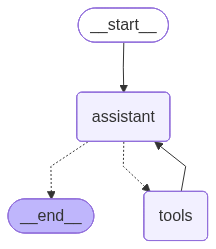

In [18]:
# The graph
builder = StateGraph(AgentState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message requires a tool, route to tools
    # Otherwise, provide a direct response
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show the butler's thought process
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

We define a tools node with our list of tools. The assistant node is just our model with bound tools. We create a graph with assistant and tools nodes.

We add a tools_condition edge, which routes to End or to tools based on whether the assistant calls a tool.

Now, we add one new step:

We connect the tools node back to the assistant, forming a loop.

After the assistant node executes, tools_condition checks if the model’s output is a tool call.

If it is a tool call, the flow is directed to the tools node.

The tools node connects back to assistant.

This loop continues as long as the model decides to call tools.

If the model response is not a tool call, the flow is directed to END, terminating the process.

In [19]:
messages = [HumanMessage(content="Divide 6790 by 5")]
messages = react_graph.invoke({"messages": messages, "input_file": None})

# Show the messages
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide 6790 by 5
================================== Ai Message ==================================
Tool Calls:
  divide (976434827)
 Call ID: 976434827
  Args:
    a: 6790
    b: 5
================================= Tool Message =================================
Name: divide

1358.0
================================== Ai Message ==================================

The result of dividing 6790 by 5 is 1358. Is there anything else I can assist you with regarding your schedules or calculations, sir?


In [20]:
messages = [HumanMessage(content="According to the note provided by Mr. Wayne in the provided images. What's the list of items I should buy for the dinner menu?")]
messages = react_graph.invoke({"messages": messages, "input_file": "Batman_training_and_meals.png"})

In [26]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

According to the note provided by Mr. Wayne in the provided images. What's the list of items I should buy for the dinner menu?
================================== Ai Message ==================================
Tool Calls:
  extract_text (546763050)
 Call ID: 546763050
  Args:
    img_path: Batman_training_and_meals.png
================================= Tool Message =================================
Name: extract_text

TRAINING SCHEDULE

SUNDAY 2/20
MORNING:
30 minute jog
30 minutes stationary bike
EVENING:
30-minute circuit class (focus on laparmor form)

MONDAY 2/21
MORNING:
30 minute jogging
30 minutes stationary bike
EVENING:
30-minute abdominal class (focus on laparmor form)

TUESDAY 2/22
MORNING:
30 minute jog
30 minutes elliptical
EVENING:
45-minute circuit class (mix of plyometrics and yoga)

WEDNESDAY 2/23
OFF DAY!

THURSDAY 2/24
MORNING:
30 minute jog
30 minutes elliptical
EVENING:
30-minute circui